In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

In [3]:
file_path = "v1_formaldehyde_lod.xlsx"
df = pd.read_excel(file_path)
df.head()

,Timestamp,Time (s),ENS160_R0 (Ohm),ENS160_R1 (Ohm),ENS160_R2 (Ohm),ENS160_R3 (Ohm),SGP41_VOC_R (Ohm),SGP41_NOx_R (Ohm),TGS2602 (Ohm)
0,2026-02-11 16:18:50.460,0.0,390827,1,123659,15110,27683,0,723.27
1,2026-02-11 16:18:51.460,1.0,396153,1,123116,15090,27910,0,723.27
2,2026-02-11 16:18:52.460,2.0,395886,1,120682,15594,28097,0,723.27
3,2026-02-11 16:18:53.460,3.0,401010,1,124078,15192,28232,0,723.27
4,2026-02-11 16:18:54.460,4.0,402369,1,124499,15172,28360,0,734.52


In [4]:
# CLEAN

# remove timestamp
df = df.drop(columns=['Timestamp']) 

# rename columns
df = df.rename(columns={"Time (s)": "Time_s",
                        "ENS160_R0 (Ohm)": "ENS160_R0",
                        "ENS160_R1 (Ohm)": "ENS160_R1",
                        "ENS160_R2 (Ohm)": "ENS160_R2",
                        "ENS160_R3 (Ohm)": "ENS160_R3",
                        "SGP41_VOC_R (Ohm)": "SGP41_VOC_R",
                        "SGP41_NOx_R (Ohm)": "SGP41_NOx_R",
                        "TGS2602 (Ohm)": "TGS2602_R"
                       })

# cutoff excess data
end_index = 59400 # 990 min * 60 s
beg_index = 1500 # remove 25 min from 30 min warmup
df = df.iloc[beg_index:end_index + 1]

# fix time_s column
df["Time_s"] = df["Time_s"] - df["Time_s"].iloc[0]

# add time (min) column
i = df.columns.get_loc("Time_s") + 1
df.insert(i, "Time_min", df["Time_s"] / 60)

# change "-" to null
df = df.replace('-', np.nan)

df.head(9)

,Time_s,Time_min,ENS160_R0,ENS160_R1,ENS160_R2,ENS160_R3,SGP41_VOC_R,SGP41_NOx_R,TGS2602_R
1500,0.0,0.000000,410485,1,112326,12371,28138,15238,524.69
1501,1.0,0.016667,408130,1,114282,12081,28146,15239,524.69
1502,2.0,0.033333,407578,1,115683,12442,28140,15241,513.88
1503,3.0,0.050000,407164,1,111342,12020,28149,15237,513.88
1504,4.0,0.066667,407302,1,112974,12139,28138,15232,524.69
1505,5.0,0.083333,407302,1,113473,12275,28140,15235,524.69
1506,6.0,0.100000,408407,1,113703,12098,28146,15233,513.88
1507,7.0,0.116667,408407,1,114942,12308,28134,15226,524.69
1508,8.0,0.133333,NaN,NaN,NaN,NaN,28141,15235,524.69


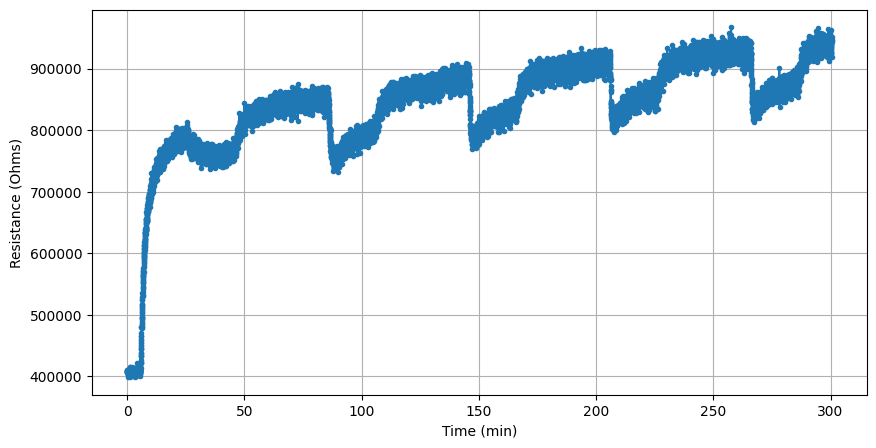

In [5]:
# plot resistances

# define segment
#plot_df = df.iloc[500:800]
plot_df = df.iloc[:18000]

# plot
plt.figure(figsize=[10,5])
plt.plot(
    plot_df["Time_min"],
    plot_df["ENS160_R0"],
    marker="o",
    linestyle="-",
    markersize=3
)
#plt.title('ENS160 R0 Resistance Output to Ethylbenzene Dosing')
plt.xlabel('Time (min)')
plt.ylabel('Resistance (Ohms)')
plt.grid()
plt.show()

In [6]:
# calculation sensor response
res_cols = ["ENS160_R0", "ENS160_R1", "ENS160_R2", "ENS160_R3", "SGP41_VOC_R", "SGP41_NOx_R", "TGS2602_R"] #define all resistance columns

for col in res_cols:
    i = df.columns.get_loc(col) + 1
    r = df[col]
    r_max = df[col].max()
    s_col = col.replace("_R", "_S")

    r = df[col].replace(0, np.nan) # avoid divide by 0
    df.insert(i, s_col, np.where(r != 0, r_max / r - 1, np.nan))

In [7]:
df.head()

,Time_s,Time_min,ENS160_R0,ENS160_S0,ENS160_R1,ENS160_S1,ENS160_R2,ENS160_S2,ENS160_R3,ENS160_S3,SGP41_VOC_R,SGP41_VOC_S,SGP41_NOx_R,SGP41_NOx_S,TGS2602_R,TGS2602_S
1500,0.0,0.000000,410485,1.601593,1,0.0,112326,2.120141,12371,8.745372,28138,0.205416,15238,0.014044,524.69,3.893499
1501,1.0,0.016667,408130,1.616605,1,0.0,114282,2.066738,12081,8.979306,28146,0.205074,15239,0.013977,524.69,3.893499
1502,2.0,0.033333,407578,1.620149,1,0.0,115683,2.029598,12442,8.68976,28140,0.205330,15241,0.013844,513.88,3.996439
1503,3.0,0.050000,407164,1.622813,1,0.0,111342,2.147716,12020,9.02995,28149,0.204945,15237,0.014110,513.88,3.996439
1504,4.0,0.066667,407302,1.621924,1,0.0,112974,2.102245,12139,8.931625,28138,0.205416,15232,0.014443,524.69,3.893499


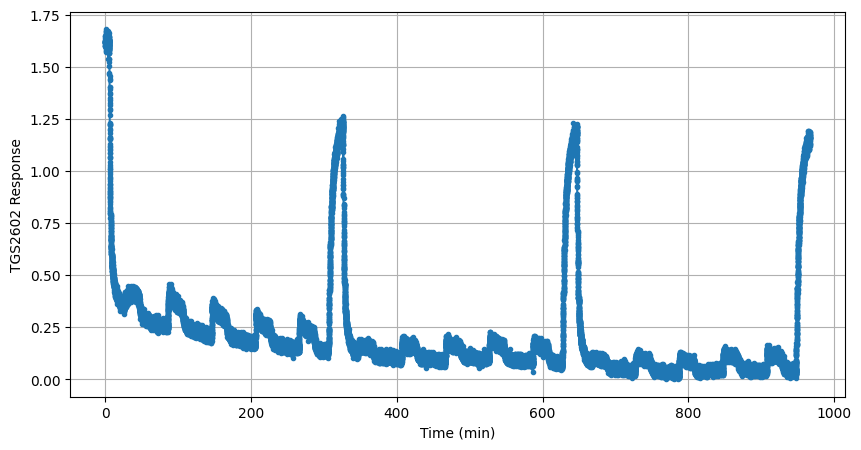

In [9]:
# plot sensitivities (response)
plt.figure(figsize=[10,5])
plt.plot(
    df["Time_min"],
    df["ENS160_S0"],
    marker="o",
    linestyle="-",
    markersize=3
)
#plt.title('ENS160 R0 Response to Ethylbenzene Dosing')
plt.xlabel('Time (min)')
plt.ylabel('TGS2602 Response')
plt.grid()
plt.show()

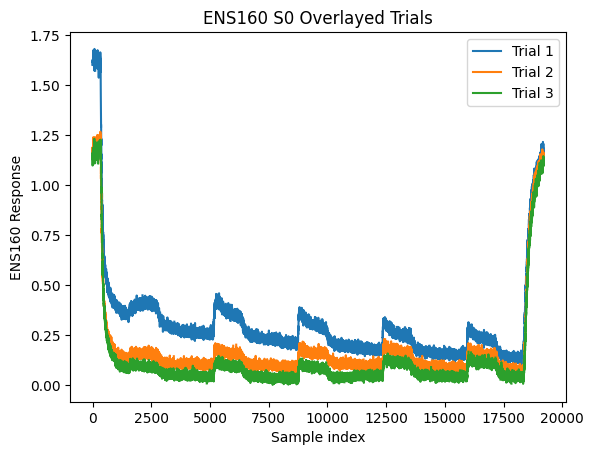

In [10]:
# check that trials are broken correctly
trial_len = 19200  # rows per trial

t1 = df.iloc[0 : trial_len]
t2 = df.iloc[trial_len : 2 * trial_len]
t3 = df.iloc[2 * trial_len : 3 * trial_len]

plt.figure()

plt.plot(
    t1.index - t1.index[0],
    t1["ENS160_S0"],
    label="Trial 1",
    markersize=2
)

plt.plot(
    t2.index - t2.index[0],
    t2["ENS160_S0"],
    label="Trial 2",
    markersize=2
)

plt.plot(
    t3.index - t3.index[0],
    t3["ENS160_S0"],
    label="Trial 3",
    markersize=2
)

plt.xlabel("Sample index")
plt.ylabel("ENS160 Response")
plt.title("ENS160 S0 Overlayed Trials")
plt.legend()
plt.show()


In [11]:
#RESHAPE BY ADDING TRIALS AS ANOTHER SET OF COLUMNS
# split trials by index
df_t1 = df.iloc[0 : trial_len].copy()
df_t2 = df.iloc[trial_len : 2 * trial_len].copy()
df_t3 = df.iloc[2 * trial_len : 3 * trial_len].copy()

# reset indices so rows align
df_t1.reset_index(drop=True, inplace=True)
df_t2.reset_index(drop=True, inplace=True)
df_t3.reset_index(drop=True, inplace=True)

# rename columns for t2 and t3
df_t1.columns = [f"{c}_t1" for c in df_t1.columns]
df_t2.columns = [f"{c}_t2" for c in df_t2.columns]
df_t3.columns = [f"{c}_t3" for c in df_t3.columns]

# concatenate column-wise
trial_df = pd.concat([df_t1, df_t2, df_t3], axis=1)

keep_mask = (
    ~trial_df.columns.str.contains("_R") &
    ~trial_df.columns.str.contains("Timestamp") &
    ~trial_df.columns.str.contains("Time_min") &
    (
        ~trial_df.columns.str.contains("Time_s") |
        trial_df.columns.str.endswith("_t1")
    )
)

trial_df = trial_df.loc[:, keep_mask].copy()

In [12]:
trial_df

,Time_s_t1,ENS160_S0_t1,ENS160_S1_t1,ENS160_S2_t1,ENS160_S3_t1,SGP41_VOC_S_t1,SGP41_NOx_S_t1,TGS2602_S_t1,ENS160_S0_t2,ENS160_S1_t2,...,SGP41_VOC_S_t2,SGP41_NOx_S_t2,TGS2602_S_t2,ENS160_S0_t3,ENS160_S1_t3,ENS160_S2_t3,ENS160_S3_t3,SGP41_VOC_S_t3,SGP41_NOx_S_t3,TGS2602_S_t3
0,0.00,1.601593,0.0,2.120141,8.745372,0.205416,0.014044,3.893499,1.161907,0.0,...,0.174243,0.053665,2.847354,1.144421,0.0,1.26452,7.399638,0.177667,0.058864,3.049156
1,1.00,1.616605,0.0,2.066738,8.979306,0.205074,0.013977,3.893499,1.165572,0.0,...,0.174853,0.053450,2.847354,1.097047,0.0,1.265281,7.297887,0.178240,0.058574,3.120969
2,2.00,1.620149,0.0,2.029598,8.68976,0.205330,0.013844,3.996439,1.188409,0.0,...,0.174934,0.053019,2.847354,1.137176,0.0,1.289955,7.394374,0.178117,0.059372,3.049156
3,3.00,1.622813,0.0,2.147716,9.02995,0.204945,0.014110,3.996439,1.166306,0.0,...,0.174649,0.053091,2.847354,1.125631,0.0,1.273732,7.494328,0.177831,0.059154,3.049156
4,4.00,1.621924,0.0,2.102245,8.931625,0.205416,0.014443,3.893499,1.143693,0.0,...,0.174649,0.053306,2.912488,1.110579,0.0,1.237857,7.508716,0.178158,0.059154,3.049156
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19195,19225.79,1.169236,0.0,1.325881,7.337483,0.174893,0.053306,2.847354,1.129951,0.0,...,0.177790,0.058936,2.979741,NaN,NaN,NaN,NaN,0.178977,0.058211,2.979741
19196,19226.79,1.157526,0.0,1.320383,7.261495,0.174365,0.052875,2.912488,1.127071,0.0,...,0.177831,0.058719,3.049156,1.116297,0.0,1.231047,7.405494,0.178813,0.058429,3.049156
19197,19227.79,1.169236,0.0,1.328245,7.323667,0.174487,0.053091,2.912488,1.128508,0.0,...,0.177872,0.059227,2.979741,1.137899,0.0,1.196579,7.416643,0.178240,0.058429,2.979741
19198,19228.79,1.148774,0.0,1.362378,7.331721,0.174893,0.053234,2.979741,NaN,NaN,...,0.177995,0.058936,2.979741,1.102021,0.0,1.207009,7.399638,0.178527,0.058356,3.049156


In [13]:
# calculate means and sds
s_cols = ["ENS160_S0", "ENS160_S1", "ENS160_S2", "ENS160_S3", "SGP41_VOC_S", "SGP41_NOx_S", "TGS2602_S"] #define all resistance columns

calc_df = pd.DataFrame()
calc_df["Time_s"] = trial_df["Time_s_t1"]

for s in s_cols:
    trial_cols = [f"{s}_t1", f"{s}_t2", f"{s}_t3"]

    calc_df[f"{s}_mean"] = trial_df[trial_cols].mean(axis=1)
    calc_df[f"{s}_std"]  = trial_df[trial_cols].std(axis=1)


In [14]:
calc_df

,Time_s,ENS160_S0_mean,ENS160_S0_std,ENS160_S1_mean,ENS160_S1_std,ENS160_S2_mean,ENS160_S2_std,ENS160_S3_mean,ENS160_S3_std,SGP41_VOC_S_mean,SGP41_VOC_S_std,SGP41_NOx_S_mean,SGP41_NOx_S_std,TGS2602_S_mean,TGS2602_S_std
0,0.00,1.30264,0.259048,0.0,0.0,1.55846,0.486607,7.821935,0.800691,0.185775,0.017095,0.042191,0.024514,3.263336,0.554986
1,1.00,1.293075,0.282273,0.0,0.0,1.555261,0.444274,7.863128,0.966666,0.186056,0.016557,0.042000,0.024403,3.287274,0.542538
2,2.00,1.315245,0.265294,0.0,0.0,1.556389,0.410896,7.779991,0.790923,0.186127,0.016706,0.042078,0.024657,3.297650,0.613523
3,3.00,1.304917,0.276056,0.0,0.0,1.582443,0.490235,7.94358,0.945501,0.185808,0.016649,0.042118,0.024444,3.297650,0.613523
4,4.00,1.292065,0.286146,0.0,0.0,1.547237,0.481707,7.934424,0.866673,0.186075,0.016842,0.042301,0.024302,3.285048,0.531347
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19195,19225.79,1.149594,0.027779,0.0,0.0,1.292901,0.046641,7.338925,0.002039,0.177220,0.002101,0.056818,0.003063,2.935612,0.076434
19196,19226.79,1.133631,0.021383,0.0,0.0,1.279943,0.045264,7.341374,0.073281,0.177003,0.002337,0.056674,0.003293,3.003600,0.078906
19197,19227.79,1.145215,0.021327,0.0,0.0,1.266953,0.066301,7.398045,0.067042,0.176866,0.002069,0.056915,0.003336,2.957324,0.038829
19198,19228.79,1.125398,0.033059,0.0,0.0,1.284694,0.109863,7.365679,0.048025,0.177138,0.001962,0.056842,0.003138,3.002880,0.040077


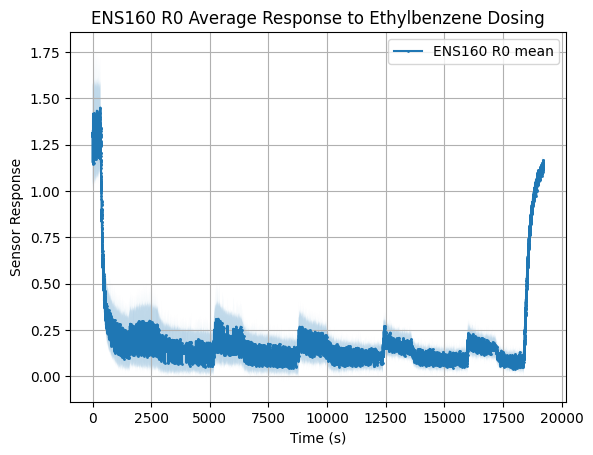

In [15]:
time = calc_df["Time_s"].astype(float).to_numpy()
avg = calc_df["ENS160_S0_mean"].astype(float).to_numpy()
std = calc_df["ENS160_S0_std"].astype(float).to_numpy()

mask = np.isfinite(time) & np.isfinite(avg) & np.isfinite(std)
time, avg, std = time[mask], avg[mask], std[mask]

line, = plt.plot(
    time,
    avg,
    label="ENS160 R0 mean",
    marker="o",
    markersize=1,
    linestyle="-"
)

plt.fill_between(
    time,
    avg - std,
    avg + std,
    alpha=0.3
)

plt.xlabel("Time (s)")
plt.ylabel("Sensor Response")
plt.title("ENS160 R0 Average Response to Ethylbenzene Dosing")
plt.legend()
plt.grid()
plt.show()

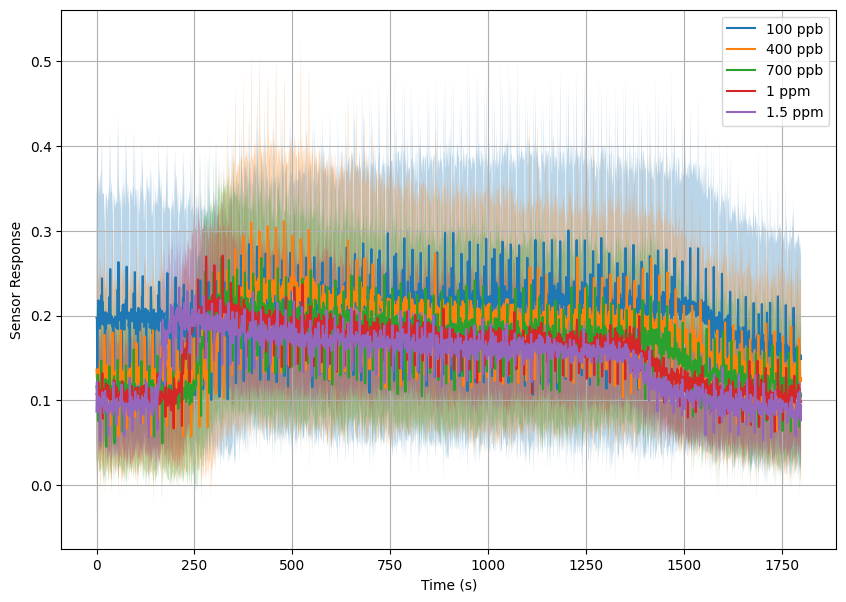

In [16]:
mask = np.isfinite(time) & np.isfinite(avg) & np.isfinite(std)
time, avg, std = time[mask], avg[mask], std[mask]

onsets = [1510, 5100, 8700, 12300, 15900]
pre = 300
post = 1500
labels = ["100 ppb", "400 ppb", "700 ppb", "1 ppm", "1.5 ppm"]
dt = 1 #s

plt.figure(figsize=[10,7])

for i, onset in enumerate(onsets):
    start = onset - pre
    end   = onset + post

    if start < 0 or end > len(avg):
        print(f"Skipping segment {i+1}: out of bounds")
        continue

    a = avg[start:end]
    s = std[start:end]
    t = np.arange(0, pre+post) * dt

    plt.plot(t, a, label=labels[i])
    plt.fill_between(t, a - s, a + s, alpha=0.3)

plt.xlabel("Time (s)")
plt.ylabel("Sensor Response")
#plt.title("ENS160 R0 Response to Ethylbenzene Dosing")
#plt.xlim([1500,4000])
#plt.ylim([0,300])
plt.legend()
plt.grid()
plt.show()


Baseline σ: 0.02862
3σ noise: 0.08585
Slope (m): -0.04772 response/ppm
Estimated LOD: -1.80 ppm
[2.49678578 2.26579013 2.04005091 1.88008264 1.72312483]
SNR at 0 ppm: 7.95
SNR at 0 ppm: 7.10
SNR at 1 ppm: 6.19
SNR at 1 ppm: 5.48
SNR at 2 ppm: 4.73


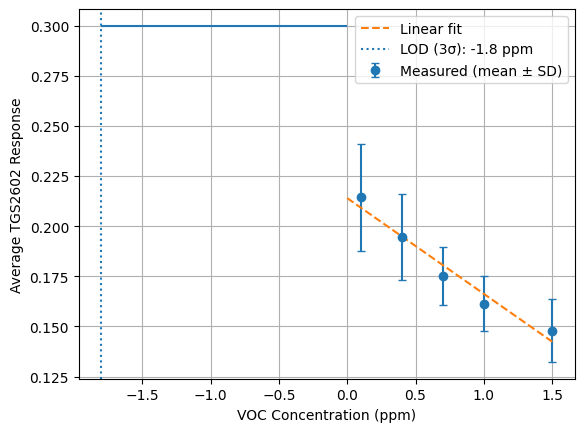

In [17]:
concs = [0.1, 0.4, 0.7, 1, 1.5] # ppm

# define baseline window
baseline_end = onsets[0] - 1
baseline_start = max(0, baseline_end - 600)  # 10 min
baseline_region = avg[baseline_start:baseline_end]

# calculate baseline noise (sigma)
sigma = np.nanstd(baseline_region, ddof=1)
noise_3sigma = 3 * sigma

# compute response from end of dosing window
pre = 900 # 15 min into dosing
post = 1140 # 19 min into dosing
avg_responses = []
err_responses = []
for onset in onsets:
    start = onset + pre
    end   = onset + post

    #find mean and SD of segment
    seg = avg[start:end]
    avg_responses.append(np.nanmean(avg[start:end]))
    err_responses.append(np.nanstd(seg, ddof=1))

# fit calibration curve
m, b = np.polyfit(concs, avg_responses, 1)  # response = m * C + b

LOD_ppm = noise_3sigma / m  # LOD = 3σ / slope
print(f"Baseline σ: {sigma:.4g}")
print(f"3σ noise: {noise_3sigma:.4g}")
print(f"Slope (m): {m:.4g} response/ppm")
print(f"Estimated LOD: {LOD_ppm:.2f} ppm")

snr = avg_responses / noise_3sigma
print(snr)
snr = 20 * np.log10(snr)
for c, s in zip(concs, snr):
    print(f"SNR at {c:.0f} ppm: {s:.2f}")

plt.figure()
# points + error bars
plt.errorbar(
    concs, avg_responses,
    yerr=err_responses,
    fmt="o",
    capsize=3,
    label="Measured (mean ± SD)"
)

# fit line, extend to LOD
x_end = max(concs[-1], LOD_ppm)
xfit = np.linspace(0, x_end, 200)
yfit = m * xfit + b
plt.plot(xfit, yfit, linestyle="--", label="Linear fit")

# LOD marker
plt.axvline(LOD_ppm, linestyle=":", label=f"LOD (3σ): {LOD_ppm:.1f} ppm")

# horizontal line at the response level where the fit hits LOD
y_at_LOD = m * LOD_ppm + b
plt.hlines(
    y=y_at_LOD,
    xmin=0,
    xmax=LOD_ppm,
)

plt.xlabel("VOC Concentration (ppm)")
plt.ylabel("Average TGS2602 Response")
#plt.title("ENS160 R0 Steady-State Response to Ethylbenzene")
plt.grid()
plt.legend()
plt.show()

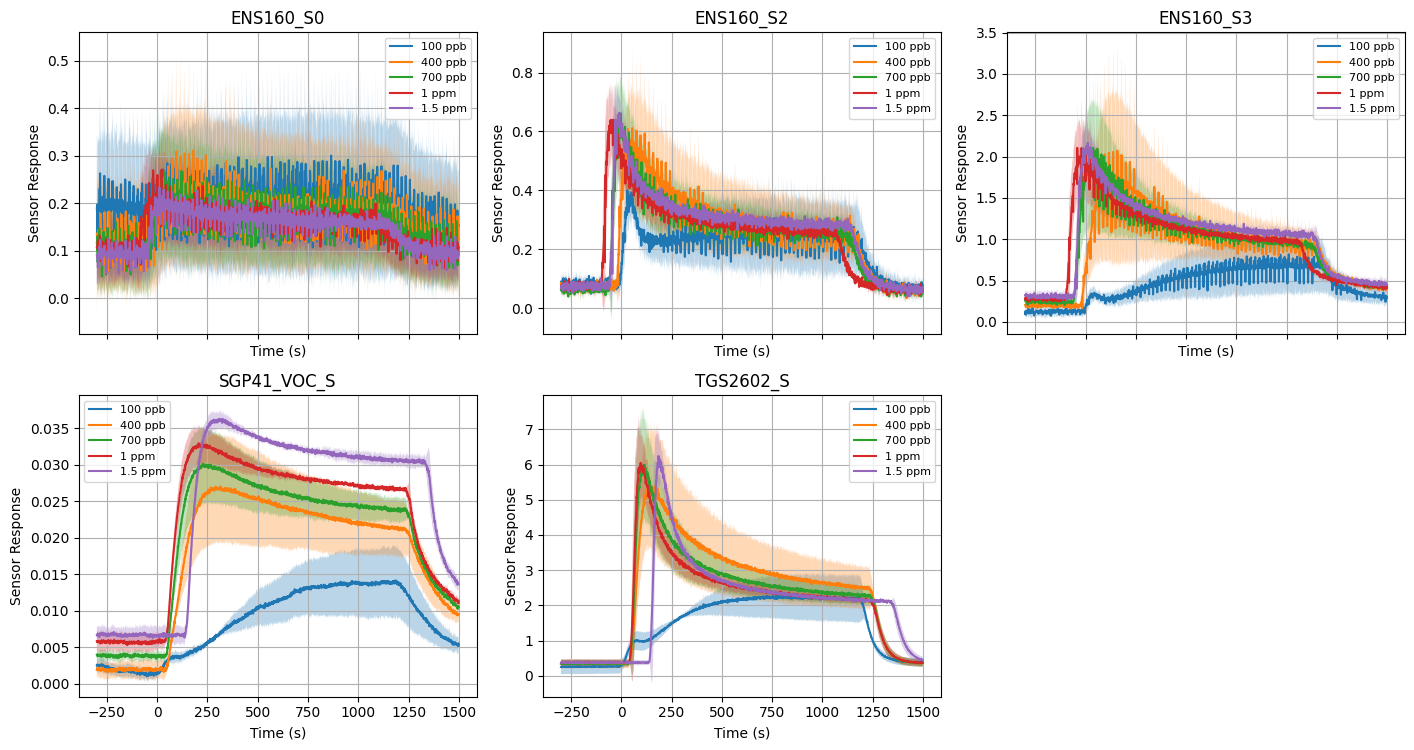

In [26]:
# PLOTS FOR ALL SENSORS
# drop
#calc_df = calc_df.drop(columns=['ENS160_S1_mean','ENS160_S1_std', 'SGP41_NOx_S_mean', 'SGP41_NOx_S_std'])

onsets = [1550, 5100, 8700, 12300, 15800]
pre = 300
post = 1500
labels = ["100 ppb", "400 ppb", "700 ppb", "1 ppm", "1.5 ppm"]
dt = 1 #s

# extract column names
cols = list(calc_df.columns)
time_col = cols[0]
sensor_cols = cols[1:] # mean & std pairs
n_sensors = len(sensor_cols) // 2

ncols = 3
nrows = int(np.ceil(n_sensors / ncols))

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(5*ncols, 4*nrows),
    sharex=True
)

axes = axes.flatten()

# loop through sensors
for i in range(n_sensors):
    ax = axes[i]

    mean_col = sensor_cols[2*i]
    std_col  = sensor_cols[2*i + 1]

    time = calc_df[time_col].astype(float).to_numpy()
    avg  = calc_df[mean_col].astype(float).to_numpy()
    std  = calc_df[std_col].astype(float).to_numpy()

    mask = np.isfinite(time) & np.isfinite(avg) & np.isfinite(std)
    avg, std = avg[mask], std[mask]

    for j, onset in enumerate(onsets):
        start = onset - pre
        end   = onset + post

        if start < 0 or end > len(avg):
            continue

        a = avg[start:end]
        s = std[start:end]
        t = np.arange(-pre, post) * dt

        n = min(len(t), len(a), len(s))
        ax.plot(t[:n], a[:n], label=labels[j])
        ax.fill_between(
            t[:n],
            (a - s)[:n],
            (a + s)[:n],
            alpha=0.3
        )

    ax.set_title(mean_col.replace("_mean", ""))
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Sensor Response")
    ax.grid(True)
    ax.legend(fontsize=8)

# hide unused subplots
for ax in axes[n_sensors:]:
    ax.axis("off")

#fig.suptitle("Sensor Responses to Ethylbenzene Dosing", fontsize=16)
plt.tight_layout(rect=[0, 0, 0.95, 0.95])
plt.show()

In [17]:
import json
voc_name = "formaldehyde"

calc_df.to_csv(f"{voc_name}_clean.csv", index=False)

meta = {
    "voc_name": "Formaldehyde",
    "unit": "ppm",
    "onsets": [1510, 5100, 8700, 12300, 15900],
    "labels": ["0.1 ppm", "0.4 ppm", "0.7 ppm", "1 ppm", "1.5 ppm"],
    "pre": 300,
    "post": 1500,
    "dt": 1
}

with open(f"{voc_name}_meta.json", "w") as f:
    json.dump(meta, f, indent=2)

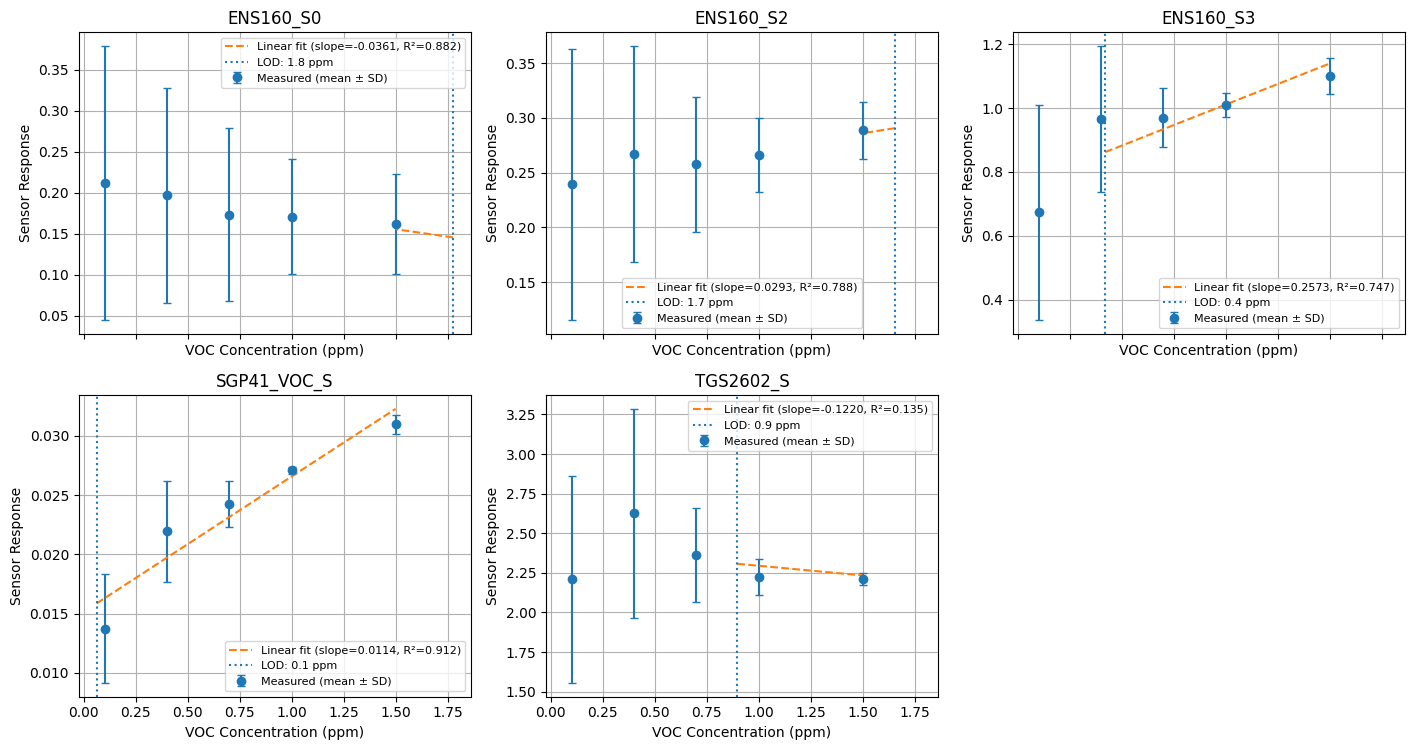

        Sensor   Slope      R2  LOD_ppm      SNR
0    ENS160_S0 -0.0361  0.8822   1.7764  18.6518
1    ENS160_S2  0.0293  0.7877   1.6556  24.2357
2    ENS160_S3  0.2573  0.7467   0.4199  28.3750
3  SGP41_VOC_S  0.0114  0.9123   0.0618  40.0360
4    TGS2602_S -0.1220  0.1354   0.8970  36.0965


In [28]:
fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(5*ncols, 4*nrows),
    sharex=True
)

axes = axes.flatten()
results = []

# loop through sensors
for i in range(n_sensors):
    ax = axes[i]

    mean_col = sensor_cols[2*i]
    std_col  = sensor_cols[2*i + 1]

    # compute response from end of dosing window
    pre = 900 # 15 min into dosing
    post = 1140 # 19 min into dosing
    avg_responses = []
    err_responses = []
    noises = []
    
    mean_data = calc_df[mean_col].values
    std_data  = calc_df[std_col].values

    # compute points + error bars + signal noise
    for onset in onsets:
        start = onset + pre
        end   = onset + post
        #find mean and SD of segment
        segment_mean = mean_data[start:end]
        segment_std  = std_data[start:end]
        avg_responses.append(np.nanmean(segment_mean))
        err_responses.append(np.sqrt(np.nanmean(segment_std**2)))
        # signal noise
        noises.append(np.nanstd(mean_data[start:end], ddof=1))
    
    # fit calibration curve
    m, b = np.polyfit(concs, avg_responses, 1)  # response = m * C + b

    # predictions and R^2
    avg_responses = np.array(avg_responses, dtype=float)
    #noises = np.array(noises, dtype=float)
    yhat = m * np.array(concs) + b
    ss_res = np.nansum((avg_responses - yhat)**2)
    ss_tot = np.nansum((avg_responses - np.nanmean(avg_responses))**2)
    R2 = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan

    # single noise estimate for this sensor
    sigma_mean = np.nanmean(noises)

    # LOD using simplified IUPAC formula
    LOD_ppm = (3 * sigma_mean) / abs(m)

    # SNR
    noise_mean = np.nanmean(noises)
    mean_response = np.nanmean(avg_responses)
    snr = mean_response / noise_mean
    snr_db = 20 * np.log10(snr)

    # points + errorbars
    ax.errorbar(
        concs, avg_responses,
        yerr=err_responses,
        fmt="o",
        capsize=3,
        label="Measured (mean ± SD)"
    )
    # fit line, extend to LOD
    x_end   = max(concs)
    xfit = np.linspace(LOD_ppm, x_end, 200)
    yfit = m * xfit + b
    ax.plot(xfit, yfit, linestyle="--", label=f"Linear fit (slope={m:.4f}, R²={R2:.3f})")

    # LOD marker
    ax.axvline(LOD_ppm, linestyle=":", label=f"LOD: {LOD_ppm:.1f} ppm")

    ax.set_title(mean_col.replace("_mean", ""))
    ax.set_xlabel("VOC Concentration (ppm)")
    ax.set_ylabel("Sensor Response")
    #ax.set_ylim(-20,300)
    ax.grid(True)
    ax.legend(fontsize=8)

    # add to results
    sensor_name = mean_col.replace("_mean", "")
    results.append({
        "Sensor": sensor_name,
        "Slope": m,
        "R2": R2,
        "LOD_ppm": LOD_ppm,
        "SNR": snr_db
    })
    
#hide unused subplots
for ax in axes[n_sensors:]:
    ax.axis("off")
    
plt.tight_layout(rect=[0, 0, 0.95, 0.95])
plt.show()

results_df = pd.DataFrame(results)
print(results_df.round(4))